In [1]:
!pip install optuna

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached MarkupSafe-3.0.2-cp313-cp313-win_amd64.whl.metadata (4.1 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 12.2 MB/s eta 0:00:00
Using cached MarkupSafe-3.0.2-cp313-cp313-win_amd64.whl (15 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

   -------- -------------------------------  2/10 [PyYAML]
   ---------------- -----------------------  4/10 [greenlet]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ ---------------  6/10 [sqlalchemy]
   ------------------------ -------------

In [4]:
# import necessary library

import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the pima Indian Diabetes dataset from sklearn
# Note: Scikit-Learn's built in "load_diabetes" is a regression dataset.
# i'll load the actual dataset from an external source

import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# split into features (X) and target (y)

X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

# split data into training and tests sets (70% train, 30% split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Optional: Scale the data for better model perfomance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# check the shape of the data
print(f"training set shaoe: {X_train.shape}")
print(f"test set shape: {X_test.shape}")

training set shaoe: (537, 8)
test set shape: (231, 8)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# define the objective function

def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators = n_estimators,
        max_depth = max_depth,
        random_state = 42
    )

    # perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv = 3, scoring = "accuracy").mean()

    return score # return the accuracy for optuna to maximize

In [8]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters


[I 2025-09-21 14:11:16,167] A new study created in memory with name: no-name-2e442104-80a1-4693-80c6-b3b0c425a3e6
[I 2025-09-21 14:11:16,929] Trial 0 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 158, 'max_depth': 14}. Best is trial 0 with value: 0.7709497206703911.
[I 2025-09-21 14:11:18,093] Trial 1 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 190, 'max_depth': 20}. Best is trial 0 with value: 0.7709497206703911.
[I 2025-09-21 14:11:18,893] Trial 2 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 160, 'max_depth': 15}. Best is trial 0 with value: 0.7709497206703911.
[I 2025-09-21 14:11:19,155] Trial 3 finished with value: 0.7541899441340782 and parameters: {'n_estimators': 58, 'max_depth': 3}. Best is trial 0 with value: 0.7709497206703911.
[I 2025-09-21 14:11:19,467] Trial 4 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 74, 'max_depth': 3}. Best is trial 0 with value: 0.77094972

In [9]:
# print the best result
print(f"Best trial accuracy: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

Best trial accuracy: 0.7821229050279329
Best hyperparameters: {'n_estimators': 119, 'max_depth': 19}


In [10]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state = 42)

# fit the model to the training data
best_model.fit(X_train, y_train)

# predict output of test data
y_pred = best_model.predict(X_test)

# calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# print the test accuracy
print(f"Test Accuracy with best hyperparameters: {test_accuracy: .2f}")


Test Accuracy with best hyperparameters:  0.74


In [11]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [12]:
# create a study and otimize it using GridSampler
study = optuna.create_study(direction = 'maximize', sampler = optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2025-09-21 14:12:00,714] A new study created in memory with name: no-name-8d4741bd-0e4d-44e8-b106-98d5613251c6
[I 2025-09-21 14:12:01,253] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-09-21 14:12:02,218] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-09-21 14:12:02,436] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-09-21 14:12:02,960] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-09-21 14:12:03,468] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [13]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 50, 'max_depth': 5}


In [14]:
from sklearn.metrics import accuracy_score

# train a randomforestclassifier using best hyperparametersfrom Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state = 42)

# fit the model
best_model.fit(X_train, y_train)

# make prediction on test data
y_pred = best_model.predict(X_test)

# calculate the accuracy score
test_accuracy = accuracy_score(y_test, y_pred)

# print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.74


# Optuna Visualization

In [15]:
# for visualization
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

### 1. Optimization_history

In [16]:
!pip install --upgrade nbformat

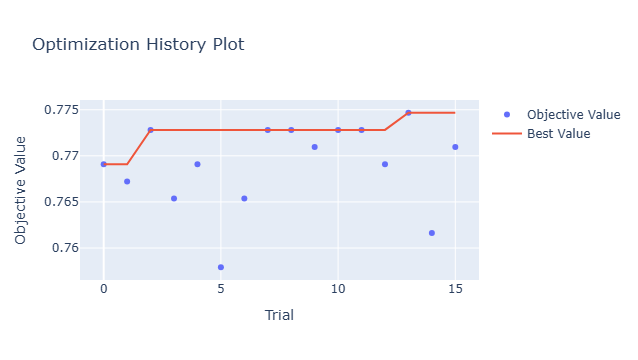

In [17]:
plot_optimization_history(study).show()

### 2. Parellel Coordinates plot

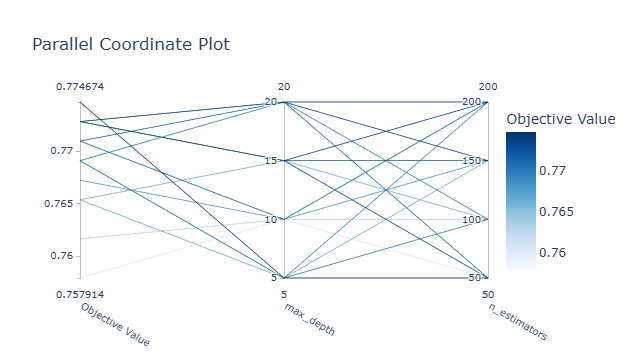

In [18]:
plot_parallel_coordinate(study).show()

### 3. slice plot

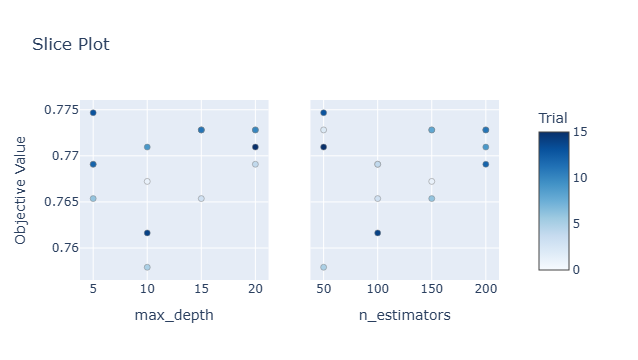

In [19]:
plot_slice(study).show()

### 4. contour plot

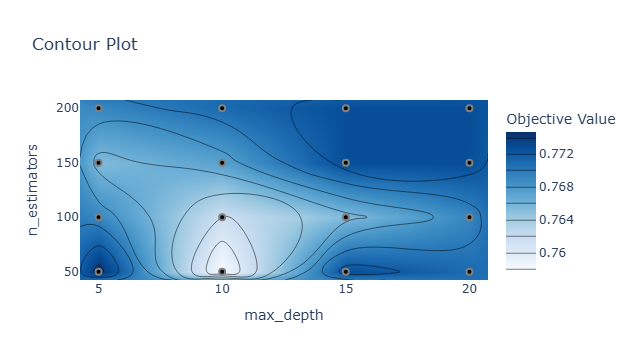

In [20]:
plot_contour(study).show()

### 5. Hyperparameter Importances

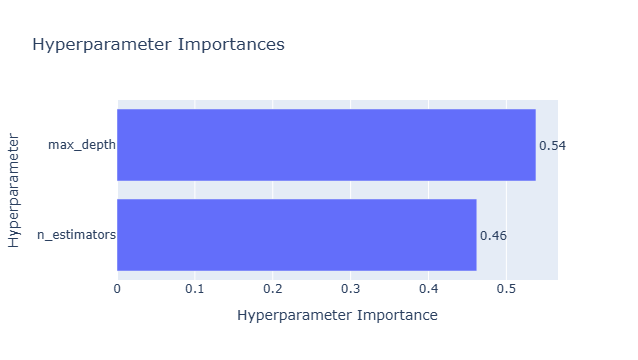

In [21]:
plot_param_importances(study).show()

In [25]:
!pip install optuna-integration[xgboost]

In [26]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")

[I 2025-09-21 14:53:09,380] A new study created in memory with name: no-name-3c996cb6-d413-4be2-bded-5b61c04ec325


[0]	train-mlogloss:0.89258	eval-mlogloss:0.88546
[1]	train-mlogloss:0.73904	eval-mlogloss:0.72134
[2]	train-mlogloss:0.62117	eval-mlogloss:0.59399
[3]	train-mlogloss:0.52419	eval-mlogloss:0.49692
[4]	train-mlogloss:0.45095	eval-mlogloss:0.42382
[5]	train-mlogloss:0.38807	eval-mlogloss:0.35420
[6]	train-mlogloss:0.33954	eval-mlogloss:0.30182
[7]	train-mlogloss:0.29647	eval-mlogloss:0.25704
[8]	train-mlogloss:0.26281	eval-mlogloss:0.22169
[9]	train-mlogloss:0.23405	eval-mlogloss:0.19045
[10]	train-mlogloss:0.20951	eval-mlogloss:0.16377
[11]	train-mlogloss:0.19124	eval-mlogloss:0.14378
[12]	train-mlogloss:0.17380	eval-mlogloss:0.12807
[13]	train-mlogloss:0.16007	eval-mlogloss:0.11303
[14]	train-mlogloss:0.15133	eval-mlogloss:0.10196
[15]	train-mlogloss:0.14214	eval-mlogloss:0.09318
[16]	train-mlogloss:0.13962	eval-mlogloss:0.08838
[17]	train-mlogloss:0.13624	eval-mlogloss:0.08504
[18]	train-mlogloss:0.13433	eval-mlogloss:0.08177
[19]	train-mlogloss:0.13139	eval-mlogloss:0.07878
[20]	train

[I 2025-09-21 14:53:09,733] Trial 0 finished with value: 1.0 and parameters: {'lambda': 2.0247297021103033e-05, 'alpha': 3.4100053911892427e-07, 'eta': 0.16649146061036868, 'gamma': 0.008135304721882956, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.7589330072838026, 'colsample_bytree': 0.7741123644386598}. Best is trial 0 with value: 1.0.


[0]	train-mlogloss:0.96266	eval-mlogloss:0.95764
[1]	train-mlogloss:0.90356	eval-mlogloss:0.89068
[2]	train-mlogloss:0.80921	eval-mlogloss:0.79053
[3]	train-mlogloss:0.71843	eval-mlogloss:0.69050
[4]	train-mlogloss:0.64529	eval-mlogloss:0.61488
[5]	train-mlogloss:0.58193	eval-mlogloss:0.54787
[6]	train-mlogloss:0.52355	eval-mlogloss:0.48367
[7]	train-mlogloss:0.47934	eval-mlogloss:0.44209
[8]	train-mlogloss:0.44130	eval-mlogloss:0.39954
[9]	train-mlogloss:0.40444	eval-mlogloss:0.36185
[10]	train-mlogloss:0.37297	eval-mlogloss:0.32656
[11]	train-mlogloss:0.34408	eval-mlogloss:0.29475
[12]	train-mlogloss:0.32486	eval-mlogloss:0.27555
[13]	train-mlogloss:0.30588	eval-mlogloss:0.25536
[14]	train-mlogloss:0.29117	eval-mlogloss:0.23946
[15]	train-mlogloss:0.27764	eval-mlogloss:0.22556
[16]	train-mlogloss:0.26835	eval-mlogloss:0.21501
[17]	train-mlogloss:0.25507	eval-mlogloss:0.20014
[18]	train-mlogloss:0.24542	eval-mlogloss:0.18942
[19]	train-mlogloss:0.23767	eval-mlogloss:0.18158
[20]	train

[I 2025-09-21 14:53:10,015] Trial 1 finished with value: 1.0 and parameters: {'lambda': 1.2168630788838054e-07, 'alpha': 7.754101470287266e-05, 'eta': 0.1100923612405695, 'gamma': 2.6295653951281108e-05, 'max_depth': 7, 'min_child_weight': 4, 'subsample': 0.41301394134864, 'colsample_bytree': 0.7370302248521633}. Best is trial 0 with value: 1.0.


...

[0]	train-mlogloss:0.99301	eval-mlogloss:0.99375


[I 2025-09-21 14:53:13,046] Trial 48 pruned. Trial was pruned at iteration 1.


[0]	train-mlogloss:0.88622	eval-mlogloss:0.87652
[1]	train-mlogloss:0.79237	eval-mlogloss:0.78709


[I 2025-09-21 14:53:13,072] Trial 49 pruned. Trial was pruned at iteration 1.


Best trial: {'lambda': 2.0247297021103033e-05, 'alpha': 3.4100053911892427e-07, 'eta': 0.16649146061036868, 'gamma': 0.008135304721882956, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.7589330072838026, 'colsample_bytree': 0.7741123644386598}
Best accuracy: 1.0


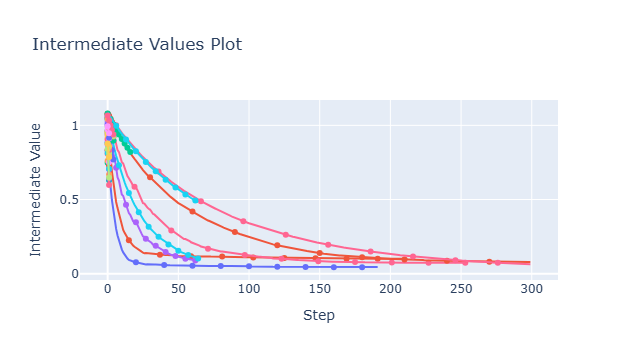

In [28]:
from optuna.visualization import plot_intermediate_values

# 1. plot intermediate values during the trials
plot_intermediate_values(study).show()